In [1]:
import os
path = os.getenv('DATA_PATH')
token = os.getenv('API_TOKEN')

In [2]:
from a3em.datasets import Arden
arden = Arden(path, token)
X_train, X_test, y_train, y_test = arden.load_data_ml(random_state=123, shuffle=True) 

prefetch complete
extracting features


100%|██████████| 62/62 [02:03<00:00,  1.99s/it]


In [3]:
X_train.head()

,peak_freq,centroid,bandwidth,freq_5,freq_95,hnr,hnr_low,mfcc_1,mfcc_2,mfcc_3,...,mel_mean_17,mel_mean_18,mel_mean_19,mel_mean_20,mel_mean_21,mel_mean_22,mel_mean_23,mel_mean_24,mel_mean_25,mel_mean_26
384,25.390625,124.204413,97.204970,24.414062,118.164062,-3.323452,2.102468,-279.243907,225.754798,22.275758,...,0.000418,0.000398,0.000174,0.000071,0.000094,0.000098,7.119411e-06,1.560064e-06,1.836936e-07,9.040752e-09
1873,21.484375,126.694161,116.887482,21.484375,123.046875,-17.626517,-14.598680,-314.020365,204.239377,21.522471,...,0.000181,0.000106,0.000095,0.000060,0.000028,0.000023,1.275716e-05,5.273153e-06,3.337014e-06,2.545278e-06
1836,22.460938,106.192751,91.614200,22.460938,124.023438,6.556033,9.614664,-270.421934,224.399038,37.934304,...,0.000728,0.000332,0.000276,0.000182,0.000130,0.000099,7.916308e-05,7.012591e-05,6.746972e-05,6.608960e-05
1134,45.898438,156.481851,109.781408,25.390625,207.031250,-23.093622,-19.976865,-407.226441,153.663643,14.548973,...,0.000220,0.000130,0.000048,0.000013,0.000006,0.000004,9.170474e-07,6.284083e-07,2.987327e-07,7.667073e-08
666,35.156250,89.265962,76.081309,22.460938,133.789062,-6.854005,-6.085540,-330.379114,242.891878,71.923608,...,0.000232,0.000127,0.000071,0.000039,0.000022,0.000015,1.132115e-05,9.919151e-06,9.378077e-06,9.222444e-06


In [4]:
y_train.head()

384     0
1873    0
1836    1
1134    0
666     0
Name: label, dtype: int64

In [5]:
X_train.to_csv('./data/train/features.csv')
X_test.to_csv('./data/test/features.csv')
y_train.to_csv('./data/train/labels.csv')
y_test.to_csv('./data/test/labels.csv')

## Analysis

In [6]:
import pandas as pd

In [7]:
train_features = pd.read_csv('./data/train/features.csv')
test_feature = pd.read_csv('./data/test/features.csv')
train_labels = pd.read_csv('./data/train/labels.csv')
test_labels = pd.read_csv('./data/test/labels.csv')

features_aggregate = pd.concat([train_features, test_feature], ignore_index=True)
labels_aggregate = pd.concat([train_labels, test_labels], ignore_index=True)

In [8]:
labels_aggregate['label'].value_counts()

label
0    1187
1     705
Name: count, dtype: int64

In [9]:
# Combine
df = train_features.copy().drop(columns=['Unnamed: 0'])
df['label'] = train_labels['label']

In [10]:
df.head()

,peak_freq,centroid,bandwidth,freq_5,freq_95,hnr,hnr_low,mfcc_1,mfcc_2,mfcc_3,...,mel_mean_18,mel_mean_19,mel_mean_20,mel_mean_21,mel_mean_22,mel_mean_23,mel_mean_24,mel_mean_25,mel_mean_26,label
0,25.390625,124.204413,97.204970,24.414062,118.164062,-3.323452,2.102468,-279.243907,225.754798,22.275758,...,0.000398,0.000174,0.000071,0.000094,0.000098,7.119411e-06,1.560064e-06,1.836936e-07,9.040752e-09,0
1,21.484375,126.694161,116.887482,21.484375,123.046875,-17.626517,-14.598680,-314.020365,204.239377,21.522471,...,0.000106,0.000095,0.000060,0.000028,0.000023,1.275716e-05,5.273153e-06,3.337014e-06,2.545278e-06,0
2,22.460938,106.192751,91.614200,22.460938,124.023438,6.556033,9.614664,-270.421934,224.399038,37.934304,...,0.000332,0.000276,0.000182,0.000130,0.000099,7.916308e-05,7.012591e-05,6.746972e-05,6.608960e-05,1
3,45.898438,156.481851,109.781408,25.390625,207.031250,-23.093622,-19.976865,-407.226441,153.663643,14.548973,...,0.000130,0.000048,0.000013,0.000006,0.000004,9.170474e-07,6.284083e-07,2.987327e-07,7.667073e-08,0
4,35.156250,89.265962,76.081309,22.460938,133.789062,-6.854005,-6.085540,-330.379114,242.891878,71.923608,...,0.000127,0.000071,0.000039,0.000022,0.000015,1.132115e-05,9.919151e-06,9.378077e-06,9.222444e-06,0


### Compute Summary Statistics

In [11]:
summary = df.groupby("label").mean()

std_summary = df.groupby("label").std()

comparison = pd.DataFrame({
    "Background Mean": df[df["label"] == 0].mean(),
    "Rumble Mean": df[df["label"] == 1].mean(),
    "Background Std": df[df["label"] == 0].std(),
    "Rumble Std": df[df["label"] == 1].std()
})

comparison = comparison.drop(index="label")
comparison

,Background Mean,Rumble Mean,Background Std,Rumble Std
peak_freq,29.628845,24.110870,9.401927,2.643652
centroid,138.505320,113.311801,30.145277,12.814566
bandwidth,116.037561,95.390718,20.453845,11.008278
freq_5,23.011845,23.072611,8.615748,2.303066
freq_95,186.797364,125.384279,70.620129,13.550382
hnr,-5.761553,0.244832,7.390642,3.500608
hnr_low,-3.571570,4.857232,8.296707,3.963902
mfcc_1,-257.917815,-283.037984,83.576843,40.454514
mfcc_2,217.026394,223.159957,17.646429,8.942999
mfcc_3,6.700205,30.610651,30.102431,16.386669


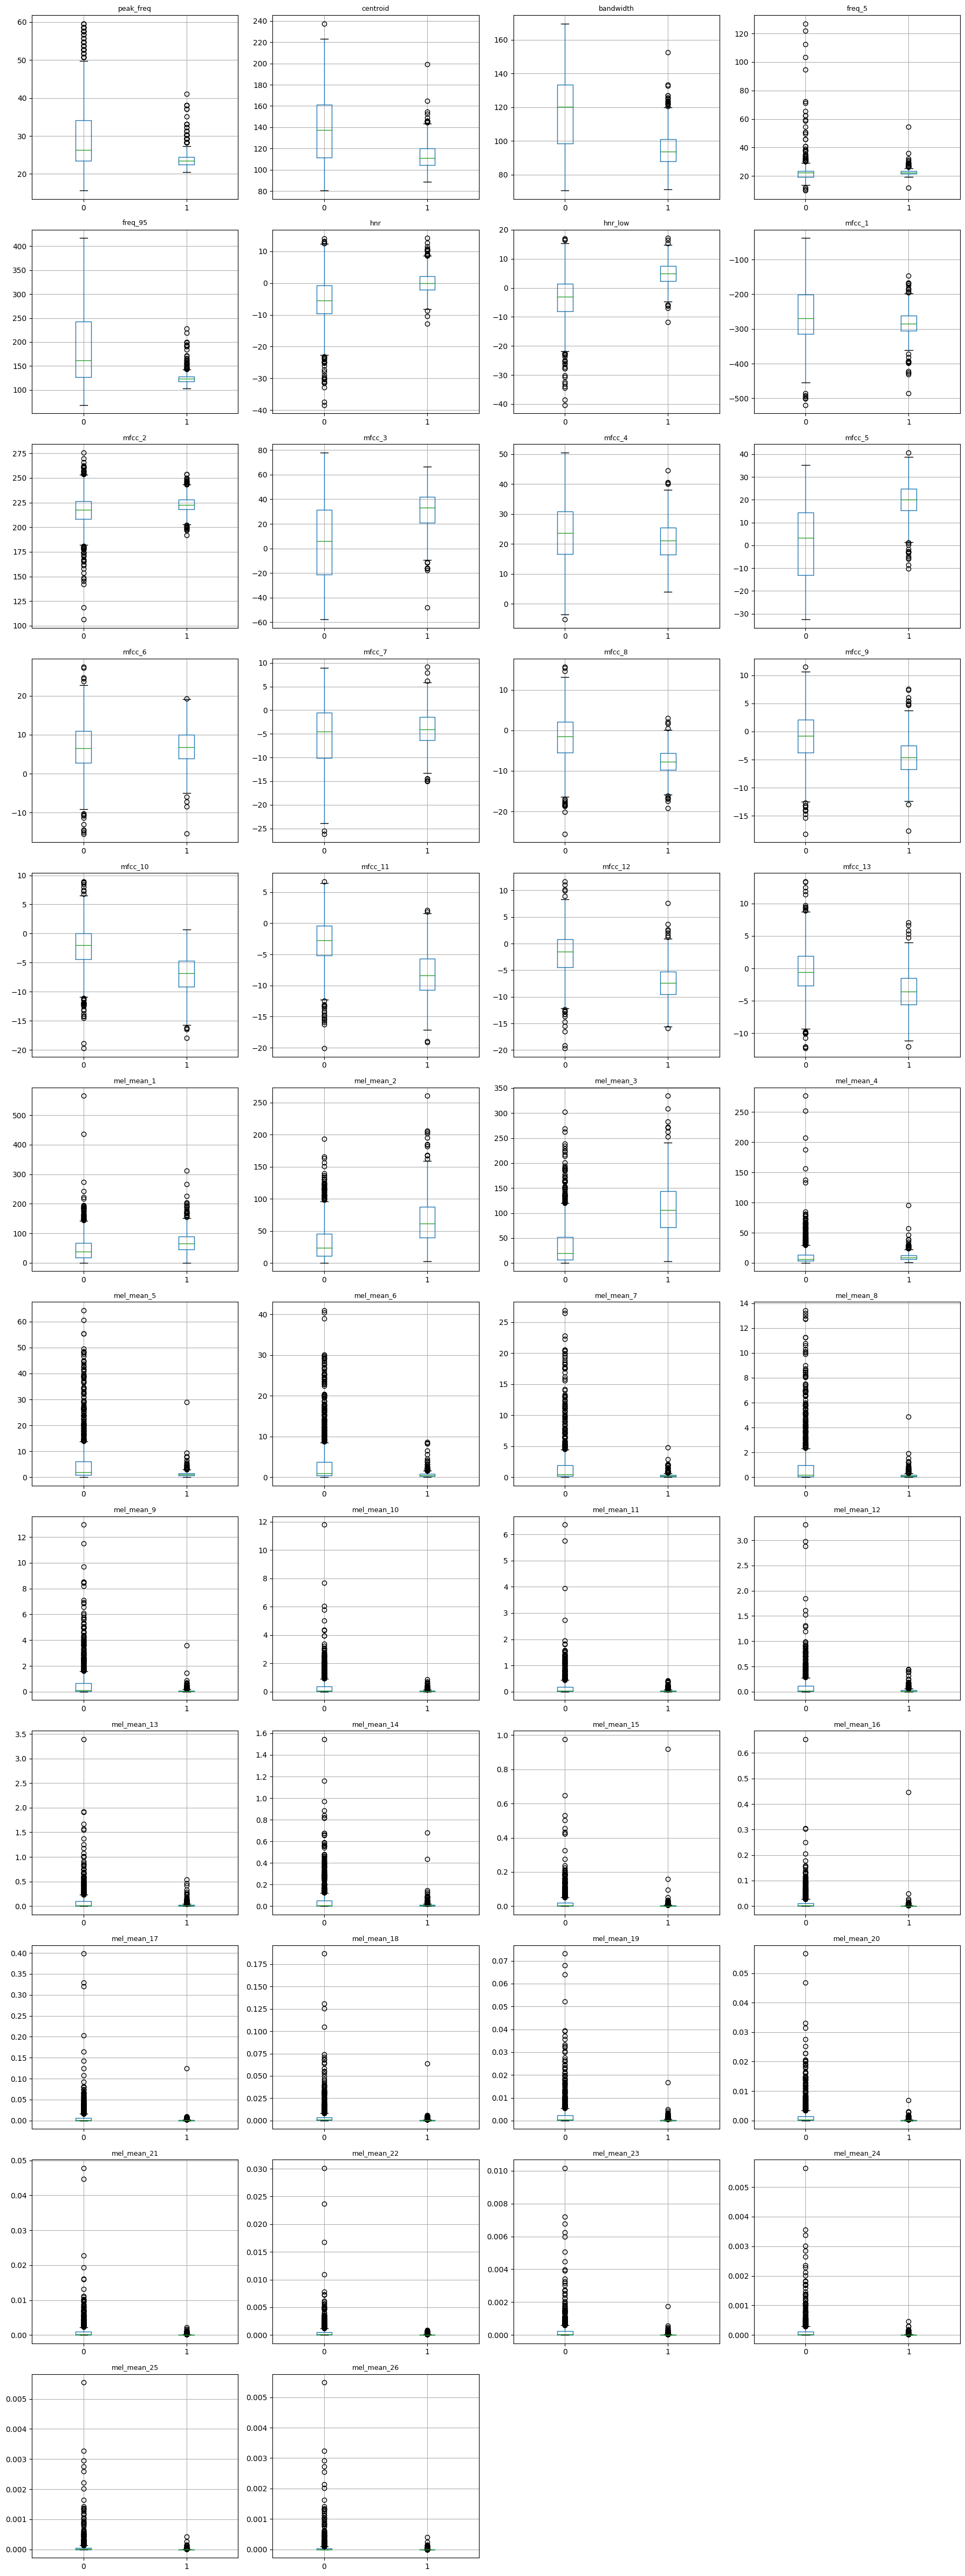

In [12]:
import matplotlib.pyplot as plt

# List of feature columns (everything except the label)
feature_cols = df.columns.drop("label")

# Determine the layout of the figure
n_features = len(feature_cols)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 4 * n_rows)
)

axes = axes.flatten()

for i, feature in enumerate(feature_cols):

    df.boxplot(
        column=feature,
        by="label",
        ax=axes[i]
    )

    axes[i].set_title(feature, fontsize=9)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("")
plt.tight_layout()

plt.show()

### Statistical Testing
Because our data does not follow a uniform distribution, we will use a **Mann-Whitney U test**

In [13]:
from scipy.stats import mannwhitneyu

In [14]:
# run the test on every feature
results = []

feature_cols = df.columns.drop("label")

for feature in feature_cols:

    background = df[df["label"] == 0][feature]
    rumble = df[df["label"] == 1][feature]

    stat, p = mannwhitneyu(
        background,
        rumble,
        alternative="two-sided"
    )

    results.append({
        "Feature": feature,
        "U Statistic": stat,
        "P Value": p
    })

results = pd.DataFrame(results)

In [15]:
# rank the features
results = results.sort_values("P Value")

results.head(20)

,Feature,U Statistic,P Value
22,mel_mean_3,74248.0,7.287067e-121
11,mfcc_5,81975.0,1.857216e-111
17,mfcc_11,447322.0,4.242758e-109
18,mfcc_12,441465.0,2.660657e-102
16,mfcc_10,440686.0,2.052796e-101
6,hnr_low,90650.0,2.339735e-101
14,mfcc_8,437905.0,2.806554e-98
4,freq_95,426642.5,4.045852e-86
2,bandwidth,418129.0,2.021768e-77
21,mel_mean_2,114351.0,3.048828e-76


In [16]:
results["Significant"] = results["P Value"] < 0.05

results.head(20)

,Feature,U Statistic,P Value,Significant
22,mel_mean_3,74248.0,7.287067e-121,True
11,mfcc_5,81975.0,1.857216e-111,True
17,mfcc_11,447322.0,4.242758e-109,True
18,mfcc_12,441465.0,2.660657e-102,True
16,mfcc_10,440686.0,2.052796e-101,True
6,hnr_low,90650.0,2.339735e-101,True
14,mfcc_8,437905.0,2.806554e-98,True
4,freq_95,426642.5,4.045852e-86,True
2,bandwidth,418129.0,2.021768e-77,True
21,mel_mean_2,114351.0,3.048828e-76,True


In [17]:
results["Significant"].value_counts()

Significant
True     45
False     1
Name: count, dtype: int64

In [18]:
results[results["Significant"] == False]

,Feature,U Statistic,P Value,Significant
12,mfcc_6,258662.0,0.393876,False


To reduce the chance of luck in our analysis, we will use a **Benjamini–Hochberg false discovery rate (FDR)** to adjust the p-va;ues

In [19]:
from statsmodels.stats.multitest import multipletests

results["Adjusted P"] = multipletests(
    results["P Value"],
    method="fdr_bh"
)[1]

results["Significant (FDR)"] = results["Adjusted P"] < 0.05

### Logistic Regression

In [20]:
print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts())
print(y_test.value_counts())

(1513, 46)
(379, 46)
label
0    959
1    554
Name: count, dtype: int64
label
0    228
1    151
Name: count, dtype: int64


In [21]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

model.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(max_iter=1000, random_state=42)

In [23]:
y_pred = model.predict(X_test_scaled)

### Classifier Evaluation

In [24]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[204  24]
 [ 19 132]]


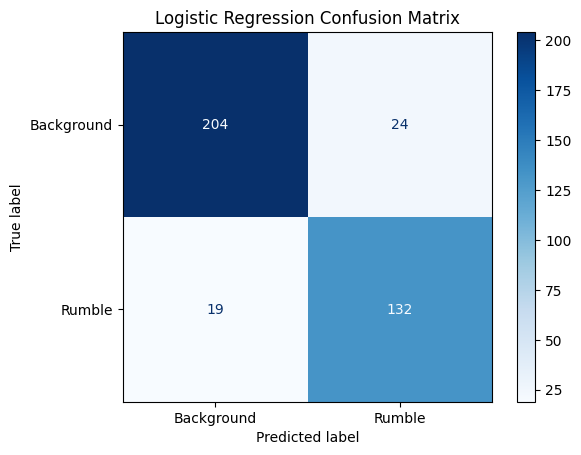

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Background", "Rumble"],
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [26]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.89      0.90       228
           1       0.85      0.87      0.86       151

    accuracy                           0.89       379
   macro avg       0.88      0.88      0.88       379
weighted avg       0.89      0.89      0.89       379



In [27]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test_scaled)[:, 1]

auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC: {auc:.3f}")

ROC-AUC: 0.936


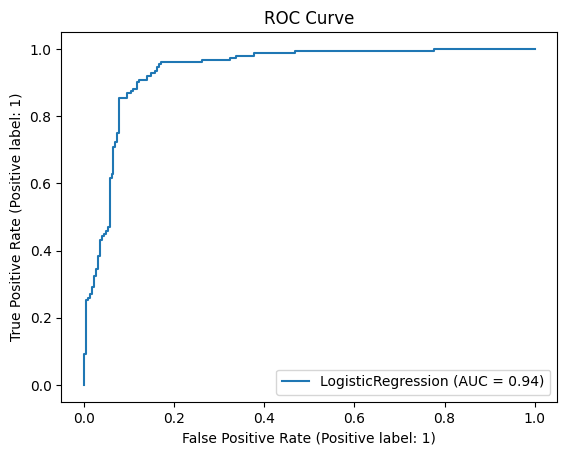

In [28]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    model,
    X_test_scaled,
    y_test
)

plt.title("ROC Curve")
plt.show()

### Feature Importance from Logistic Regression

In [29]:
import pandas as pd

coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_[0]
})

coefficients["Absolute Coefficient"] = (
    coefficients["Coefficient"].abs()
)

coefficients = coefficients.sort_values(
    "Absolute Coefficient",
    ascending=False
)

coefficients.head(10)

,Feature,Coefficient,Absolute Coefficient
6,hnr_low,2.482739,2.482739
5,hnr,-2.073480,2.073480
45,mel_mean_26,-1.371377,1.371377
44,mel_mean_25,-1.214604,1.214604
4,freq_95,-1.130545,1.130545
0,peak_freq,-0.879145,0.879145
14,mfcc_8,-0.688386,0.688386
24,mel_mean_5,-0.682092,0.682092
9,mfcc_3,-0.673606,0.673606
11,mfcc_5,0.618686,0.618686


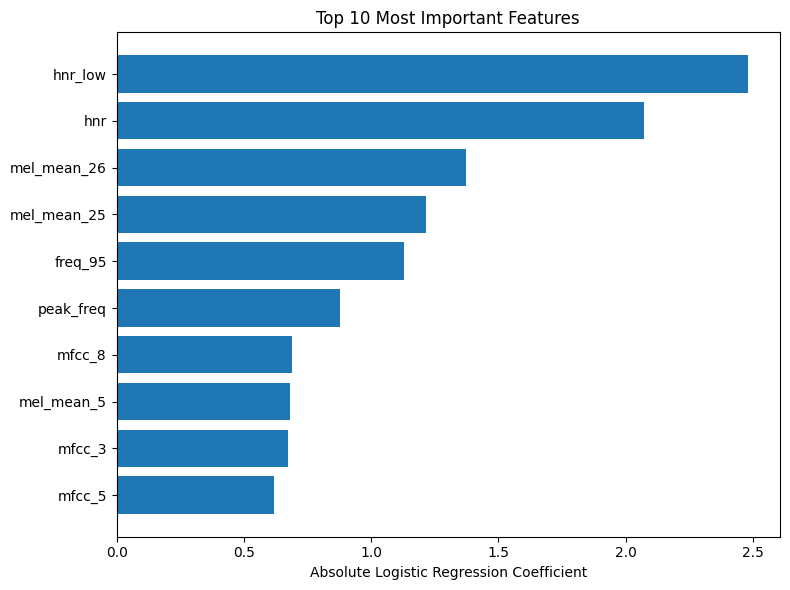

In [30]:
import matplotlib.pyplot as plt

top10 = coefficients.head(10)

plt.figure(figsize=(8,6))

plt.barh(
    top10["Feature"],
    top10["Absolute Coefficient"]
)

plt.xlabel("Absolute Logistic Regression Coefficient")
plt.title("Top 10 Most Important Features")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [31]:
feature_summary = coefficients.merge(
    results,
    on="Feature"
)

feature_summary = feature_summary.sort_values(
    "Absolute Coefficient",
    ascending=False
)

feature_summary.head(10)

,Feature,Coefficient,Absolute Coefficient,U Statistic,P Value,Significant,Adjusted P,Significant (FDR)
0,hnr_low,2.482739,2.482739,90650.0,2.339735e-101,True,1.793797e-100,True
1,hnr,-2.073480,2.073480,120911.0,6.224964e-70,True,2.603167e-69,True
2,mel_mean_26,-1.371377,1.371377,390408.0,1.950324e-52,True,4.721837e-52,True
3,mel_mean_25,-1.214604,1.214604,402388.0,1.263455e-62,True,4.843243e-62,True
4,freq_95,-1.130545,1.130545,426642.5,4.045852e-86,True,2.326365e-85,True
5,peak_freq,-0.879145,0.879145,356150.0,8.645669e-29,True,1.169708e-28,True
6,mfcc_8,-0.688386,0.688386,437905.0,2.806554e-98,True,1.844307e-97,True
7,mel_mean_5,-0.682092,0.682092,369815.0,4.368465e-37,True,7.728823e-37,True
8,mfcc_3,-0.673606,0.673606,138344.0,1.630319e-54,True,4.166371e-54,True
9,mfcc_5,0.618686,0.618686,81975.0,1.857216e-111,True,4.271597e-110,True


### Cross Validation with Random Forest

In [32]:
from sklearn.ensemble import RandomForestClassifier

In [33]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

In [34]:
rf_model.fit(
    X_train,
    y_train
)

RandomForestClassifier(n_estimators=200, random_state=42)

In [35]:
rf_pred = rf_model.predict(X_test)

In [36]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    rf_pred
))

              precision    recall  f1-score   support

           0       0.90      0.87      0.89       228
           1       0.81      0.86      0.84       151

    accuracy                           0.87       379
   macro avg       0.86      0.86      0.86       379
weighted avg       0.87      0.87      0.87       379



### RandomForest Feature Importance

In [37]:
import pandas as pd

rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    "Importance",
    ascending=False
)

rf_importance.head(15)

,Feature,Importance
6,hnr_low,0.083452
22,mel_mean_3,0.075491
14,mfcc_8,0.059253
18,mfcc_12,0.052859
11,mfcc_5,0.052199
5,hnr,0.048358
16,mfcc_10,0.041068
4,freq_95,0.040903
17,mfcc_11,0.039873
2,bandwidth,0.037598


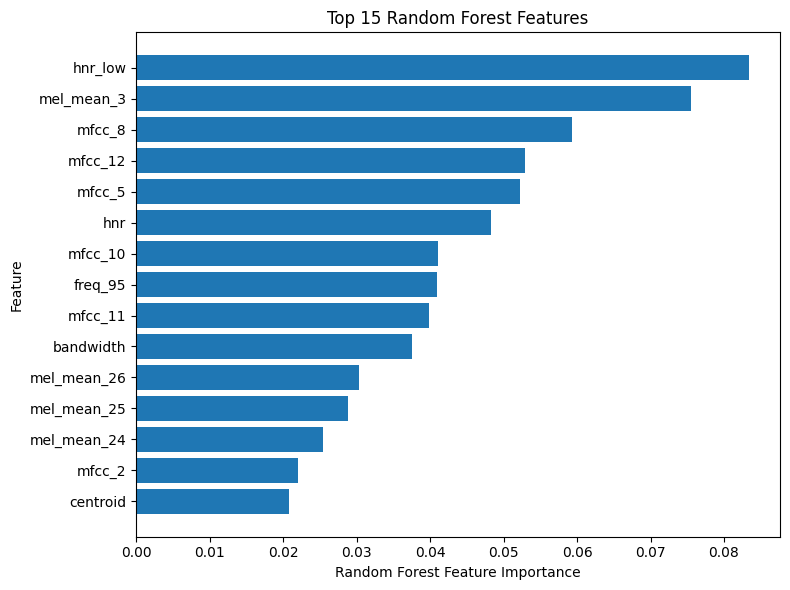

In [38]:
import matplotlib.pyplot as plt

top15 = rf_importance.head(15)

plt.figure(figsize=(8,6))

plt.barh(
    top15["Feature"],
    top15["Importance"]
)

plt.xlabel("Random Forest Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Features")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [39]:
# Mann-Whitney U ranking
mw_rank = results.copy()

mw_rank = mw_rank.sort_values("P Value")

mw_rank["MW Rank"] = range(1, len(mw_rank)+1)

mw_rank = mw_rank[[
    "Feature",
    "MW Rank",
    "P Value"
]]

# Logistic Regression ranking
lr_rank = coefficients.copy()

lr_rank = lr_rank.sort_values(
    "Absolute Coefficient",
    ascending=False
)

lr_rank["LR Rank"] = range(1, len(lr_rank)+1)

lr_rank = lr_rank[[
    "Feature",
    "Coefficient",
    "Absolute Coefficient",
    "LR Rank"
]]

# Random Forest ranking
rf_rank = rf_importance.copy()

rf_rank = rf_rank.sort_values(
    "Importance",
    ascending=False
)

rf_rank["RF Rank"] = range(1, len(rf_rank)+1)

rf_rank = rf_rank[[
    "Feature",
    "Importance",
    "RF Rank"
]]

# merge
comparison = (
    mw_rank
    .merge(lr_rank, on="Feature")
    .merge(rf_rank, on="Feature")
)

# add overall ranking
comparison["Average Rank"] = (
    comparison["MW Rank"] +
    comparison["LR Rank"] +
    comparison["RF Rank"]
) / 3
comparison = comparison.sort_values("Average Rank")
comparison = comparison[[
    "Feature",
    "P Value",
    "Coefficient",
    "Importance",
    "MW Rank",
    "LR Rank",
    "RF Rank",
    "Average Rank"
]]

comparison.head(20)

,Feature,P Value,Coefficient,Importance,MW Rank,LR Rank,RF Rank,Average Rank
5,hnr_low,2.339735e-101,2.482739,0.083452,6,1,1,2.666667
1,mfcc_5,1.857216e-111,0.618686,0.052199,2,10,5,5.666667
6,mfcc_8,2.806554e-98,-0.688386,0.059253,7,7,3,5.666667
10,hnr,6.224964e-70,-2.073480,0.048358,11,2,6,6.333333
7,freq_95,4.045852e-86,-1.130545,0.040903,8,5,8,7.000000
2,mfcc_11,4.242758e-109,-0.388496,0.039873,3,16,9,9.333333
11,mel_mean_25,1.263455e-62,-1.214604,0.028858,12,4,12,9.333333
4,mfcc_10,2.052796e-101,-0.338695,0.041068,5,18,7,10.000000
18,mel_mean_26,1.950324e-52,-1.371377,0.030378,19,3,11,11.000000
12,mel_mean_24,1.985634e-62,-0.550083,0.025484,13,11,13,12.333333
